In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import importlib, helper
importlib.reload(helper)
from helper import MODEL_W_REASONING, KEYWORDS
from helper import get_text_labels, transform

NameError: name 're' is not defined

# put thinking in dataframe

In [94]:
def process_to_csv(lang, model, output_csv="reasoning_labels_per_episode.csv"):
    """
    Memory-efficient CSV writing - writes each row immediately.
    <LANG>/<MODEL>/<GAME>/<EXPERIMENT>/<INSTANCE>/interactions_with_thinking.json
    """
    root = Path(f"../results_{lang}/{model}")
    json_files = list(root.glob("*/*/*/interactions_with_thinking.json"))
    total = len(json_files)
    
    file_exists = os.path.isfile(output_csv)
    
    with open(output_csv, "a", newline="", encoding="utf-8") as csvfile:
        writer = csv.writer(csvfile)
    
        # write header only if file did not exist before
        if not file_exists:
            writer.writerow([
                "lang", "model", "game", "experiment", "episode",
                "reasoning_raw", "reasoning_labels"
            ])

        for i, json_file in enumerate(json_files):
            episode = json_file.parent.name
            experiment = json_file.parent.parent.name
            game = json_file.parent.parent.parent.name

            print(f"lang: {lang}; model: {model}")
            print(f"[{i+1}/{total}] Processing: {game}/{experiment}/{episode}")
            
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                reasoning_raw_r = extract_reasoning(data)
                reasoning_raw = json.dumps(reasoning_raw_r)
                reasoning_labels_r = [
                    get_text_labels(e['action']['content'], lang=lang, debug=False) 
                    for e in reasoning_events
                ]
                reasoning_labels = json.dumps(reasoning_labels_r)
                
                writer.writerow([lang, model, game, experiment, episode, 
                               reasoning_raw, reasoning_labels])
                
                # Flush to disk periodically
                if (i + 1) % 10 == 0:
                    csvfile.flush()
                
                # Clean up
                del data, extracted, extracted_json
                
                # Garbage collect periodically
                if (i + 1) % 20 == 0:
                    gc.collect()
                    
            except KeyboardInterrupt:
                print(f"\n⚠️  Interrupted at {i}/{total}")
                break
            except Exception as e:
                print(f"  ❌ Error: {e}")
                # Write error row with empty data
                writer.writerow([lang, model, game, experiment, instance, 
                               json.dumps({"error": str(e)}), "[]"])
                continue
    
    print(f"\n✓ Completed: {output_csv}")
    gc.collect()

In [95]:
def extract_reasoning(data): 
    # extract the 1st turn only
    extracted = []
    for obj in data['turns'][0]: 
        if obj['action']['type'] == "thinking": 
            extracted.append(obj)

    return extracted

In [96]:
for lang in KEYWORDS: 
    for model in MODEL_W_REASONING: 
        process_to_csv_streaming(lang, model)


✓ Completed: reasoning_labels_per_episode.csv
lang: en; model: claude-sonnet-4-20250514-t0.0
[1/98] Processing: dond/semi_en/instance_00001
  ❌ Error: name 'reasoning_events' is not defined


NameError: name 'instance' is not defined

# labeling reasoning traces

In [4]:
df = pd.read_csv('results.csv')
df.head()

,lang,model,game,experiment,instance,raw_reasoning
0,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00001,"[{""from"": ""Player 1"", ""to"": ""Player 1"", ""times..."
1,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00004,"[{""from"": ""Player 1"", ""to"": ""Player 1"", ""times..."
2,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00005,"[{""from"": ""Player 1"", ""to"": ""Player 1"", ""times..."
3,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00000,"[{""from"": ""Player 1"", ""to"": ""Player 1"", ""times..."
4,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00008,"[{""from"": ""Player 1"", ""to"": ""Player 1"", ""times..."


In [5]:
df["raw_reasoning"] = df["raw_reasoning"].apply(json.loads)
df.head()

,lang,model,game,experiment,instance,raw_reasoning
0,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00001,"[{'from': 'Player 1', 'to': 'Player 1', 'times..."
1,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00004,"[{'from': 'Player 1', 'to': 'Player 1', 'times..."
2,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00005,"[{'from': 'Player 1', 'to': 'Player 1', 'times..."
3,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00000,"[{'from': 'Player 1', 'to': 'Player 1', 'times..."
4,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00008,"[{'from': 'Player 1', 'to': 'Player 1', 'times..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   lang           503 non-null    object
 1   model          503 non-null    object
 2   game           503 non-null    object
 3   experiment     503 non-null    object
 4   instance       503 non-null    object
 5   raw_reasoning  503 non-null    object
dtypes: object(6)
memory usage: 23.7+ KB


In [8]:
df["reasoning_labels"] = df["raw_reasoning"].apply(
    lambda cell: [get_text_labels(ele['action']['content'], debug=False) for ele in cell] # omg printing is so expensive..
)

In [9]:
df.head()

,lang,model,game,experiment,instance,raw_reasoning,reasoning_labels
0,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00001,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, PROPOSE], [CONCLUD..."
1,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00004,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, CONCLUDE, PROPOSE]..."
2,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00005,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[ASSERT, PROPOSE], [ASSERT, UNDERMINE, PROPOS..."
3,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00000,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT], [CONCLUDE, ASSERT..."
4,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00008,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, ASSERT], [PROPOSE,..."


In [13]:
df['reasoning_chain_len'] = df['reasoning_labels'].apply(
    lambda cell: [len(ele) for ele in cell]
)

In [14]:
df.head()

,lang,model,game,experiment,instance,raw_reasoning,reasoning_labels,reasoning_chain_len
0,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00001,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, PROPOSE], [CONCLUD...","[4, 4]"
1,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00004,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, CONCLUDE, PROPOSE]...","[5, 3]"
2,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00005,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[ASSERT, PROPOSE], [ASSERT, UNDERMINE, PROPOS...","[2, 4]"
3,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00000,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT], [CONCLUDE, ASSERT...","[3, 6]"
4,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00008,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, ASSERT], [PROPOSE,...","[4, 2]"


In [17]:
df['reasoning_chain_avg_len'] = df['reasoning_chain_len'].apply(lambda cell: sum(cell) / len(cell))

In [19]:
df.head()

,lang,model,game,experiment,instance,raw_reasoning,reasoning_labels,reasoning_chain_len,reasoning_chain_avg_len
0,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00001,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, PROPOSE], [CONCLUD...","[4, 4]",4.0
1,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00004,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, CONCLUDE, PROPOSE]...","[5, 3]",4.0
2,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00005,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[ASSERT, PROPOSE], [ASSERT, UNDERMINE, PROPOS...","[2, 4]",3.0
3,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00000,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT], [CONCLUDE, ASSERT...","[3, 6]",4.5
4,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00008,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, ASSERT], [PROPOSE,...","[4, 2]",3.0


In [21]:
df.groupby(['model'])['reasoning_chain_avg_len'].mean()

model
claude-sonnet-4-20250514-t0.0           2.783163
deepseek-r1-distill-llama-70b-t1.0     70.794073
gpt-oss-120b-t1.0                      20.537954
nemotron-nano-9b-v2-t1.0              104.354167
qwen3-next-80b-a3b-thinking-t1.0      218.879538
Name: reasoning_chain_avg_len, dtype: float64

In [22]:
df.to_csv("reasoning_labels_en.csv")

# correlate reasoning_chain_avg_len with Main Score

In [70]:
df_score = transform(pd.read_csv(f"../results_en/raw.csv"))
df_score.head()

metric,game,model,experiment,episode,Model Type,reasoning,Aborted,Main Score,Success
0,clean_up,claude-sonnet-4-20250514-no-reasoning-t0.0,0_easy_3obj_en,instance_00000,commercial,No,0,88.461538,1
1,clean_up,claude-sonnet-4-20250514-no-reasoning-t0.0,0_easy_3obj_en,instance_00001,commercial,No,0,92.857143,1
2,clean_up,claude-sonnet-4-20250514-no-reasoning-t0.0,0_easy_3obj_en,instance_00002,commercial,No,0,83.333333,1
3,clean_up,claude-sonnet-4-20250514-no-reasoning-t0.0,0_easy_5obj_en,instance_00000,commercial,No,0,75.000000,1
4,clean_up,claude-sonnet-4-20250514-no-reasoning-t0.0,0_easy_5obj_en,instance_00001,commercial,No,0,95.454545,1


In [71]:
df_merge = df.merge(
    df_score,
    left_on=['model', 'game', 'experiment', 'instance'],
    right_on=['model', 'game', 'experiment', 'episode'],
    how='inner'  
)[['model', 'game', 'experiment', 'instance', 
   'reasoning_chain_avg_len', 
   'Model Type', 'Main Score', 'Aborted', 'Success']]


In [72]:
df_merge.head()

,model,game,experiment,instance,reasoning_chain_avg_len,Model Type,Main Score,Aborted,Success
0,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00001,4.0,commercial,100.0,0,1
1,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00004,4.0,commercial,0.0,0,0
2,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00005,3.0,commercial,90.0,0,1
3,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00000,4.5,commercial,100.0,0,1
4,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00008,3.0,commercial,100.0,0,1


In [73]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   model                    503 non-null    object 
 1   game                     503 non-null    object 
 2   experiment               503 non-null    object 
 3   instance                 503 non-null    object 
 4   reasoning_chain_avg_len  503 non-null    float64
 5   Model Type               503 non-null    object 
 6   Main Score               381 non-null    float64
 7   Aborted                  503 non-null    int64  
 8   Success                  503 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 35.5+ KB


In [74]:
df_corr = df_merge.groupby('model', as_index=False).agg({
  'reasoning_chain_avg_len': 'mean', 
  'Main Score': 'mean', 
  'Model Type': 'first'
})
df_corr.head() 

,model,reasoning_chain_avg_len,Main Score,Model Type
0,claude-sonnet-4-20250514-t0.0,2.783163,90.453800,commercial
1,deepseek-r1-distill-llama-70b-t1.0,70.794073,29.161982,open-weight
2,gpt-oss-120b-t1.0,20.537954,74.553940,open-weight
3,nemotron-nano-9b-v2-t1.0,104.354167,34.013465,open-weight
4,qwen3-next-80b-a3b-thinking-t1.0,218.879538,80.244265,open-weight


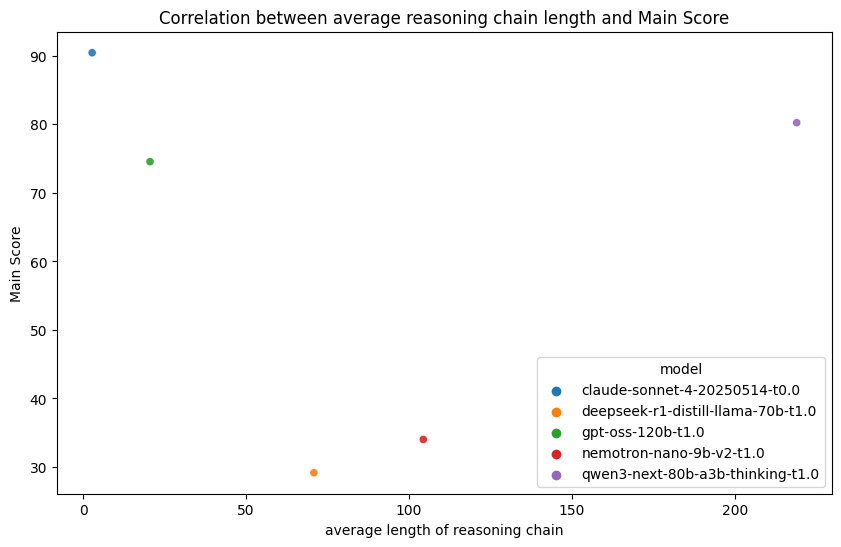

In [75]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_corr, x='reasoning_chain_avg_len', y='Main Score', alpha=0.9, hue="model")
plt.title('Correlation between average reasoning chain length and Main Score')
plt.xlabel('average length of reasoning chain')
plt.ylabel('Main Score')
plt.show()

In [ ]:
# make plot for separate games 
# make another plot for clemscore